# 💳 Análise Exploratória — Gastos de Cartão de Crédito (jan–jun/2026)

**Autor:** Josué Suman | **Projeto de portfólio — Análise de Dados**

## Contexto

Este notebook analisa 6 meses de faturas de um cartão de crédito a partir do extrato bruto (`extrato_cartao_2026.csv`). A base chega **suja**, como acontece no mundo real: datas em múltiplos formatos, valores como texto (`R$`, vírgula decimal), duplicatas, nulos e inconsistências de grafia.

## Objetivos

1. **Diagnosticar e tratar** os problemas de qualidade dos dados, documentando cada decisão;
2. **Explorar** os padrões de consumo (evolução mensal, categorias, dia/hora, assinaturas, parcelamentos);
3. **Responder às perguntas de negócio** e fechar com recomendações acionáveis de economia.

## Sumário

1. [Setup](#1)
2. [Carga e primeira inspeção](#2)
3. [Diagnóstico de qualidade](#3)
4. [Limpeza dos dados](#4)
5. [Enriquecimento (feature engineering)](#5)
6. [Análise exploratória](#6)
7. [Conclusões e recomendações](#7)
8. [Rastreabilidade — números do dashboard](#8)

<a id="1"></a>
## 1. Setup

Importamos as bibliotecas e definimos configurações globais de exibição e estilo dos gráficos.

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exibição: mais colunas visíveis e valores com 2 casas decimais
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)

# Estilo padrão dos gráficos
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.titlesize"] = 13

ARQUIVO = "extrato_cartao_2026.csv"

<a id="2"></a>
## 2. Carga e primeira inspeção

Carregamos o CSV **sem conversões automáticas** (`dtype=str` para as colunas problemáticas seria uma opção; aqui deixamos o pandas inferir e observamos o que ele encontra). O objetivo desta etapa é *conhecer* a base antes de alterá-la.

In [2]:
df_raw = pd.read_csv(ARQUIVO)

print(f"Dimensões: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
df_raw.head(8)

Dimensões: 513 linhas x 10 colunas


,id_transacao,data_hora,estabelecimento,categoria,valor,cidade,pais,tipo_pagamento,parcelas,titular
0,TX1099,2026-01-01 16:59:51,DROGARIA SAO PAULO,Farmacia,106.15,Sao Paulo,BR,credito_a_vista,1,JOSUE S SILVA
1,TX1412,2026-01-01 17:01:19,STARBUCKS BR,Cafeteria,28.89,Sao Paulo,BR,credito_a_vista,1,JOSUE S SILVA
2,TX1251,2026-01-02 09:55:09,99APP *99APP,Transporte,32.22,Sao Paulo,BR,credito_a_vista,1,JOSUE S SILVA
3,TX1441,02/01/2026 14:08,CARREFOUR HIPER,Supermercado,350.12,Sao Paulo,BR,credito_a_vista,1,JOSUE S SILVA
4,TX1383,2026-01-02 21:59:10,IFOOD *RESTAURANTE,Delivery,53.48,Sao Paulo,BR,credito_a_vista,1,JOSUE S SILVA - ADICIONAL
5,TX1086,03/01/2026 09:04,MAGAZINE LUIZA,E-commerce,646.64,Sao Paulo,BR,credito_a_vista,1,JOSUE S SILVA
6,TX1388,2026-01-03 12:36:38,SUPERMERCADO PAO DE ACUCAR,Supermercado,R$ 119.70,Sao Paulo,BR,credito_a_vista,1,JOSUE S SILVA - ADICIONAL
7,TX1442,2026-01-03 13:32:29,IFOOD *RESTAURANTE,Delivery,51.12,Sao Paulo,BR,credito_a_vista,1,JOSUE S SILVA


In [3]:
# Tipos inferidos e contagem de não-nulos por coluna
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_transacao     513 non-null    object
 1   data_hora        513 non-null    object
 2   estabelecimento  513 non-null    object
 3   categoria        493 non-null    object
 4   valor            513 non-null    object
 5   cidade           503 non-null    object
 6   pais             513 non-null    object
 7   tipo_pagamento   513 non-null    object
 8   parcelas         513 non-null    int64 
 9   titular          513 non-null    object
dtypes: int64(1), object(9)
memory usage: 40.2+ KB


**O que já podemos observar:**

- `data_hora` e `valor` foram lidos como `object` (texto) — sinal de formatos inconsistentes;
- `categoria` e `cidade` têm menos não-nulos que o total de linhas → **valores ausentes**;
- Precisamos verificar duplicatas antes de qualquer agregação.

<a id="3"></a>
## 3. Diagnóstico de qualidade

Antes de corrigir, **medimos** cada problema. Isso permite mostrar o "antes e depois" da limpeza — boa prática para auditar o processo.

In [4]:
diagnostico = {
    "Linhas totais": len(df_raw),
    "Duplicatas exatas": df_raw.duplicated().sum(),
    "IDs de transação repetidos": df_raw["id_transacao"].duplicated().sum(),
    "Categoria nula/vazia": df_raw["categoria"].isna().sum(),
    "Cidade nula/vazia": df_raw["cidade"].isna().sum(),
    "Valores com vírgula decimal": df_raw["valor"].str.contains(",", na=False).sum(),
    "Valores com prefixo 'R$'": df_raw["valor"].str.contains("R\\$", na=False).sum(),
    "Datas no formato DD/MM/AAAA": df_raw["data_hora"].str.contains("/", na=False).sum(),
    "Datas ISO com 'T'": df_raw["data_hora"].str.contains("T", na=False).sum(),
    "Estabelecimentos em minúsculas": df_raw["estabelecimento"].str.islower().sum(),
}
pd.Series(diagnostico, name="ocorrências").to_frame()

,ocorrências
Linhas totais,513
Duplicatas exatas,5
IDs de transação repetidos,8
Categoria nula/vazia,20
Cidade nula/vazia,10
Valores com vírgula decimal,44
Valores com prefixo 'R$',26
Datas no formato DD/MM/AAAA,58
Datas ISO com 'T',20
Estabelecimentos em minúsculas,25


In [5]:
# Exemplos concretos de cada formato problemático (evidência do diagnóstico)
print("— Formatos de data encontrados:")
print(df_raw.loc[df_raw["data_hora"].str.contains("/", na=False), "data_hora"].head(2).to_list())
print(df_raw.loc[df_raw["data_hora"].str.contains("T", na=False), "data_hora"].head(2).to_list())
print()
print("— Formatos de valor encontrados:")
print(df_raw.loc[df_raw["valor"].str.contains(",", na=False), "valor"].head(2).to_list())
print(df_raw.loc[df_raw["valor"].str.contains("R\\$", na=False), "valor"].head(2).to_list())
print()
print("— Grafias distintas de categoria (amostra):")
print(sorted(df_raw["categoria"].dropna().unique())[:12])

— Formatos de data encontrados:
['02/01/2026 14:08', '03/01/2026 09:04']
['2026-01-31T12:49:16', '2026-02-15T00:01:00']

— Formatos de valor encontrados:
['72,47', '388,94']
['R$ 119.70', 'R$ 240.25']

— Grafias distintas de categoria (amostra):
['Academia', 'Cafeteria', 'Casa e Construcao', 'Casa e Decoracao', 'Combustivel', 'Delivery', 'E-commerce', 'Educacao', 'Estacionamento', 'Farmacia', 'Lazer', 'Padaria']


**Resumo do diagnóstico** — a base tem 6 classes de problema:

| # | Problema | Estratégia de tratamento |
|---|---|---|
| 1 | Linhas duplicadas (mesmo `id_transacao`) | Remover, mantendo a 1ª ocorrência |
| 2 | 3 formatos de data misturados | Parser tolerante a múltiplos formatos |
| 3 | Valor como texto (`,` decimal, prefixo `R$`) | Normalizar string → `float` |
| 4 | Nulos em `categoria` | Imputar pela categoria mais comum do mesmo estabelecimento |
| 5 | Nulos em `cidade` | Preencher como "Nao Informado" (volume baixo, sem impacto nas análises-chave) |
| 6 | Caixa/espaços inconsistentes | Normalizar (`strip`, caixa padronizada) |

<a id="4"></a>
## 4. Limpeza dos dados

Trabalharemos em uma **cópia** (`df`), preservando `df_raw` como referência do estado original.

### 4.1 Datas — unificando 3 formatos

Os formatos presentes são `YYYY-MM-DD HH:MM:SS`, `DD/MM/YYYY HH:MM` e `YYYY-MM-DDTHH:MM:SS`. Usamos `pd.to_datetime` com `format="mixed"` e `dayfirst=False`, mas **atenção**: com formatos mistos o pandas pode interpretar `05/01/2026` como 1º de maio. Por segurança, tratamos o formato brasileiro separadamente — abordagem explícita é preferível a "mágica" que silenciosamente troca dia e mês.

In [6]:
df = df_raw.copy()

# Máscara: linhas no formato brasileiro DD/MM/YYYY
mask_br = df["data_hora"].str.contains("/", na=False)

df["data_hora_dt"] = pd.NaT
# Formato BR: dia primeiro
df.loc[mask_br, "data_hora_dt"] = pd.to_datetime(
    df.loc[mask_br, "data_hora"], format="%d/%m/%Y %H:%M"
)
# Demais (ISO com espaço ou com 'T'): to_datetime resolve nativamente
df.loc[~mask_br, "data_hora_dt"] = pd.to_datetime(df.loc[~mask_br, "data_hora"], format="mixed")

df["data_hora_dt"] = pd.to_datetime(df["data_hora_dt"])

# Validação: nenhuma data deve ter falhado nem cair fora da janela jan-jun/2026
assert df["data_hora_dt"].isna().sum() == 0, "Há datas não convertidas!"
assert df["data_hora_dt"].min().year == 2026 and df["data_hora_dt"].max().month <= 6
print(f"OK — período: {df['data_hora_dt'].min()} a {df['data_hora_dt'].max()}")

OK — período: 2026-01-01 16:59:51 a 2026-06-30 22:51:24


### 4.2 Valores — de texto para `float`

Removemos o prefixo `R$`, espaços e convertemos vírgula decimal em ponto. Valores **negativos são estornos** e serão mantidos: eles reduzem corretamente o gasto líquido nas agregações.

In [7]:
def limpar_valor(v: str) -> float:
    """Converte '123.45', '123,45' ou 'R$ 123.45' em float."""
    v = str(v).replace("R$", "").strip()
    # Se há vírgula, ela é o separador decimal (padrão BR desta base)
    if "," in v:
        v = v.replace(".", "").replace(",", ".")
    return float(v)

df["valor_num"] = df["valor"].apply(limpar_valor)

assert df["valor_num"].isna().sum() == 0
print(f"OK — faixa de valores: R$ {df['valor_num'].min():,.2f} a R$ {df['valor_num'].max():,.2f}")
print(f"Estornos (valores negativos): {(df['valor_num'] < 0).sum()} transações")

OK — faixa de valores: R$ -672.20 a R$ 1,795.42
Estornos (valores negativos): 3 transações


### 4.3 Duplicatas

Removemos linhas com `id_transacao` repetido — o ID é a chave da transação, então a repetição é erro de extração, não compra dupla legítima (uma compra repetida de verdade teria ID próprio).

In [8]:
antes = len(df)
df = df.drop_duplicates(subset="id_transacao", keep="first").copy()
print(f"Removidas {antes - len(df)} duplicatas — base agora com {len(df)} transações únicas.")

Removidas 8 duplicatas — base agora com 505 transações únicas.


### 4.4 Normalização de texto e extração de parcelas

Duas tarefas: (a) padronizar caixa e espaços em `estabelecimento` e `categoria`; (b) o nome de compras parceladas vem com sufixo `2/6` — extraímos o número da parcela para uma coluna própria e limpamos o nome, permitindo agrupar todas as parcelas de um mesmo lojista.

In [9]:
# (a) Normalização de caixa e espaços
df["estabelecimento"] = df["estabelecimento"].str.upper().str.strip()
df["categoria"] = df["categoria"].str.strip().str.title()

# (b) Extração do sufixo de parcela 'i/n' do fim do nome
padrao_parcela = re.compile(r"\s(\d{1,2})/(\d{1,2})$")

df["num_parcela"] = df["estabelecimento"].str.extract(padrao_parcela)[0].astype("Int64")
df["estabelecimento_limpo"] = df["estabelecimento"].str.replace(padrao_parcela, "", regex=True)

# Conferência: parceladas devem ter num_parcela preenchido
df.loc[df["tipo_pagamento"] == "credito_parcelado",
       ["estabelecimento", "estabelecimento_limpo", "num_parcela", "parcelas"]].head(6)

,estabelecimento,estabelecimento_limpo,num_parcela,parcelas
35,MAGAZINE LUIZA 1/6,MAGAZINE LUIZA,1,6
55,CASAS BAHIA 1/10,CASAS BAHIA,1,10
81,DECOLAR.COM 1/4,DECOLAR.COM,1,4
114,MAGAZINE LUIZA 2/6,MAGAZINE LUIZA,2,6
131,CASAS BAHIA 2/10,CASAS BAHIA,2,10
157,DECOLAR.COM 2/4,DECOLAR.COM,2,4


### 4.5 Imputação de categoria

Para os nulos em `categoria`, usamos o próprio dado: **a categoria mais frequente do mesmo estabelecimento**. É uma imputação de baixa incerteza, pois cada lojista tem categoria única na prática. O que sobrar (estabelecimento sem nenhuma categoria conhecida) vira `"Nao Classificado"`.

In [10]:
nulos_antes = df["categoria"].isna().sum()

# Mapa estabelecimento -> categoria mais frequente (moda)
mapa_cat = (
    df.dropna(subset=["categoria"])
      .groupby("estabelecimento_limpo")["categoria"]
      .agg(lambda s: s.mode()[0])
)

df["categoria"] = df["categoria"].fillna(df["estabelecimento_limpo"].map(mapa_cat))
df["categoria"] = df["categoria"].fillna("Nao Classificado")

# Cidade: volume baixo de nulos e coluna secundária -> marcador explícito
df["cidade"] = df["cidade"].fillna("Nao Informado")

print(f"Categorias imputadas: {nulos_antes - (df['categoria'] == 'Nao Classificado').sum()} pelo estabelecimento")
print(f"Restantes como 'Nao Classificado': {(df['categoria'] == 'Nao Classificado').sum()}")

Categorias imputadas: 19 pelo estabelecimento
Restantes como 'Nao Classificado': 0


### 4.6 Validação final da limpeza

Fechamos a etapa com um "antes e depois" — evidência de que a base está pronta para análise.

In [11]:
df = df.drop(columns=["data_hora", "valor"]).rename(
    columns={"data_hora_dt": "data_hora", "valor_num": "valor"}
)

resumo = pd.DataFrame({
    "Antes (bruto)": {
        "Linhas": len(df_raw),
        "Duplicatas": df_raw.duplicated(subset="id_transacao").sum(),
        "Categoria nula": df_raw["categoria"].isna().sum(),
        "Tipo de data_hora": str(df_raw["data_hora"].dtype),
        "Tipo de valor": str(df_raw["valor"].dtype),
    },
    "Depois (limpo)": {
        "Linhas": len(df),
        "Duplicatas": df.duplicated(subset="id_transacao").sum(),
        "Categoria nula": df["categoria"].isna().sum(),
        "Tipo de data_hora": str(df["data_hora"].dtype),
        "Tipo de valor": str(df["valor"].dtype),
    },
})
resumo

,Antes (bruto),Depois (limpo)
Linhas,513,505
Duplicatas,8,0
Categoria nula,20,0
Tipo de data_hora,object,datetime64[ns]
Tipo de valor,object,float64


<a id="5"></a>
## 5. Enriquecimento (feature engineering)

Criamos colunas derivadas que sustentam as análises:

- **`mes`** e **`dia_semana`** — sazonalidade;
- **`hora`** e **`periodo_do_dia`** — padrões de horário;
- **`is_assinatura`** — serviços recorrentes (streaming, academia, cursos);
- **`is_internacional`** — compras fora do Brasil;
- **`is_estorno`** — valores negativos.

In [12]:
MESES = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun"}
DIAS = {0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"}
ASSINATURAS = ["NETFLIX.COM", "SPOTIFY", "AMAZON PRIME",
               "GOOGLE *YOUTUBEPREMIUM", "SMARTFIT", "ALURA CURSOS"]

df["mes_num"] = df["data_hora"].dt.month
df["mes"] = df["mes_num"].map(MESES)
df["dia_semana_num"] = df["data_hora"].dt.dayofweek
df["dia_semana"] = df["dia_semana_num"].map(DIAS)
df["hora"] = df["data_hora"].dt.hour

df["periodo_do_dia"] = pd.cut(
    df["hora"], bins=[-1, 5, 11, 17, 23],
    labels=["Madrugada", "Manha", "Tarde", "Noite"]
)

df["is_assinatura"] = df["estabelecimento_limpo"].isin(ASSINATURAS)
df["is_internacional"] = df["pais"] != "BR"
df["is_estorno"] = df["valor"] < 0

df[["data_hora", "estabelecimento_limpo", "valor", "mes", "dia_semana",
    "periodo_do_dia", "is_assinatura", "is_internacional"]].sample(5, random_state=1)

,data_hora,estabelecimento_limpo,valor,mes,dia_semana,periodo_do_dia,is_assinatura,is_internacional
311,2026-04-26 09:51:57,CARREFOUR HIPER,445.19,Abr,Dom,Manha,False,False
351,2026-05-08 22:19:31,CLINICA ODONTO SORRIA,155.79,Mai,Sex,Noite,False,False
48,2026-01-20 01:08:00,GOOGLE *YOUTUBEPREMIUM,28.90,Jan,Ter,Madrugada,True,False
68,2026-01-28 17:27:22,SUPERMERCADO PAO DE ACUCAR,349.56,Jan,Qua,Tarde,False,False
369,2026-05-14 21:15:00,MAGAZINE LUIZA,399.98,Mai,Qui,Noite,False,False


<a id="6"></a>
## 6. Análise exploratória

### 6.1 Visão geral dos números

In [13]:
gasto_total = df["valor"].sum()  # líquido (estornos já descontam)
print(f"Gasto líquido no semestre: R$ {gasto_total:,.2f}")
print(f"Média mensal:              R$ {gasto_total / 6:,.2f}")
print(f"Ticket médio por compra:   R$ {df.loc[~df['is_estorno'], 'valor'].mean():,.2f}")
print(f"Maior compra:              R$ {df['valor'].max():,.2f} "
      f"({df.loc[df['valor'].idxmax(), 'estabelecimento_limpo']})")

df.loc[~df["is_estorno"], "valor"].describe().to_frame("valor (R$)")

Gasto líquido no semestre: R$ 74,066.76
Média mensal:              R$ 12,344.46
Ticket médio por compra:   R$ 149.54
Maior compra:              R$ 1,795.42 (DECOLAR.COM)


,valor (R$)
count,502.00
mean,149.54
std,184.14
min,10.16
25%,40.47
50%,76.09
75%,189.90
max,"1,795.42"


### 6.2 Evolução do gasto mensal

**Pergunta de negócio 1:** qual a evolução do gasto? Há tendência de alta?

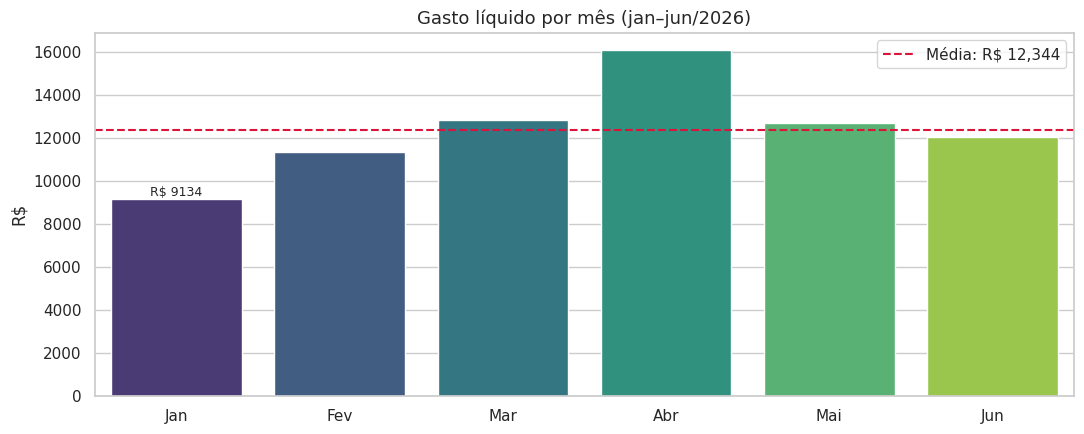

Variação jun vs jan: +31.8%


In [14]:
gasto_mensal = df.groupby(["mes_num", "mes"])["valor"].sum().reset_index()

ax = sns.barplot(data=gasto_mensal, x="mes", y="valor", hue="mes", legend=False)
ax.axhline(gasto_mensal["valor"].mean(), ls="--", c="crimson",
           label=f"Média: R$ {gasto_mensal['valor'].mean():,.0f}")
ax.bar_label(ax.containers[0], fmt="R$ %.0f", fontsize=9)
ax.set(title="Gasto líquido por mês (jan–jun/2026)", xlabel="", ylabel="R$")
ax.legend()
plt.tight_layout()
plt.show()

var_pct = (gasto_mensal["valor"].iloc[-1] / gasto_mensal["valor"].iloc[0] - 1) * 100
print(f"Variação jun vs jan: {var_pct:+.1f}%")

### 6.3 Onde o dinheiro vai — gasto por categoria

**Pergunta 2:** quais categorias mais pesam e como variam mês a mês?

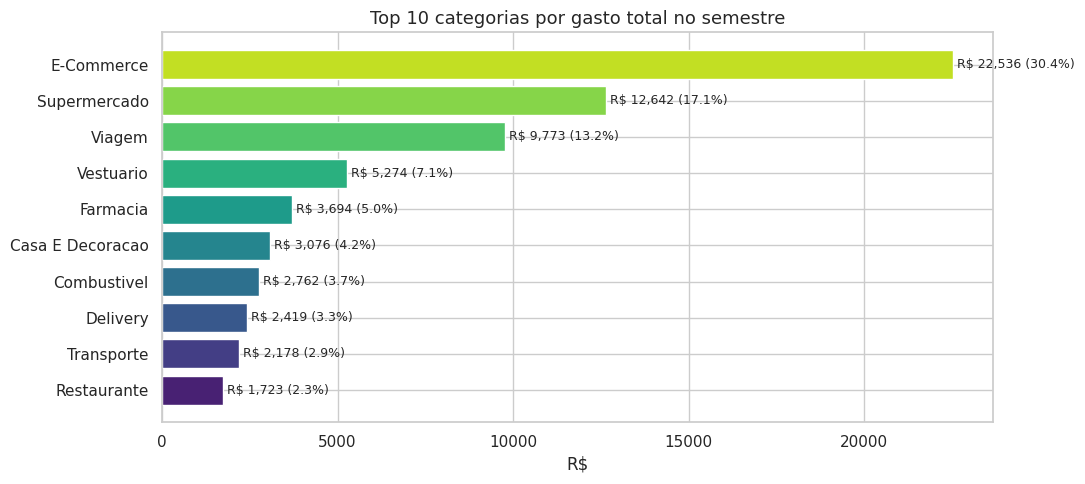

,total,transacoes,ticket_medio,% do total
categoria,,,,
E-Commerce,"22,535.53",81,278.22,30.43
Supermercado,"12,641.85",71,178.05,17.07
Viagem,"9,772.55",11,888.41,13.19
Vestuario,"5,273.89",26,202.84,7.12
Farmacia,"3,694.25",38,97.22,4.99
Casa E Decoracao,"3,075.77",9,341.75,4.15
Combustivel,"2,762.25",14,197.30,3.73
Delivery,"2,418.86",44,54.97,3.27
Transporte,"2,177.80",64,34.03,2.94


In [15]:
por_categoria = (
    df.groupby("categoria")["valor"]
      .agg(total="sum", transacoes="count", ticket_medio="mean")
      .sort_values("total", ascending=False)
)
por_categoria["% do total"] = por_categoria["total"] / por_categoria["total"].sum() * 100

fig, ax = plt.subplots(figsize=(11, 5))
top10 = por_categoria.head(10).iloc[::-1]
ax.barh(top10.index, top10["total"], color=sns.color_palette("viridis", 10))
for i, (total, pct) in enumerate(zip(top10["total"], top10["% do total"])):
    ax.text(total, i, f" R$ {total:,.0f} ({pct:.1f}%)", va="center", fontsize=9)
ax.set(title="Top 10 categorias por gasto total no semestre", xlabel="R$")
plt.tight_layout()
plt.show()

por_categoria.head(10)

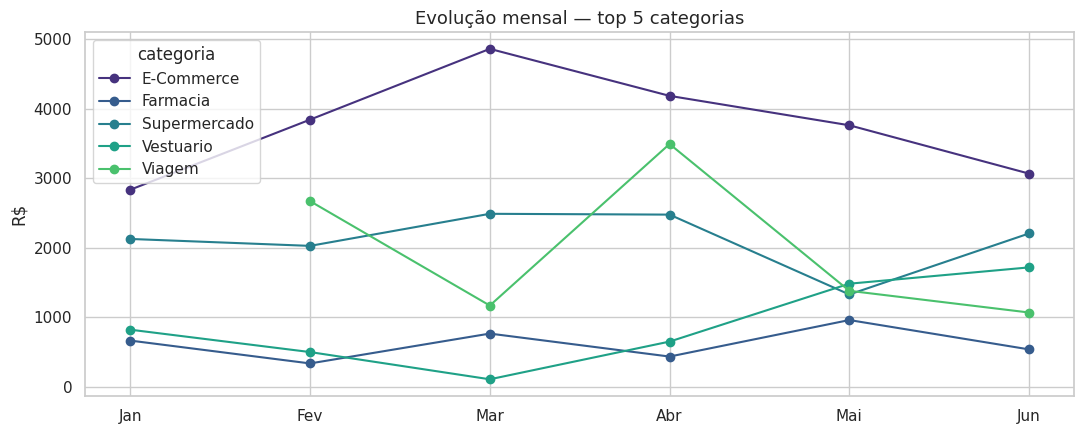

In [16]:
# Evolução mensal das 5 maiores categorias
top5 = por_categoria.head(5).index
pivot_cat = (
    df[df["categoria"].isin(top5)]
      .pivot_table(index="mes_num", columns="categoria", values="valor", aggfunc="sum")
      .rename(index=MESES)
)
ax = pivot_cat.plot(marker="o", figsize=(11, 4.5))
ax.set(title="Evolução mensal — top 5 categorias", xlabel="", ylabel="R$")
plt.tight_layout()
plt.show()

### 6.4 Padrão temporal — dia da semana × hora

**Pergunta 6:** existe padrão de gasto por dia da semana e horário? O heatmap abaixo mostra a *quantidade* de transações (volume de uso do cartão); a mesma visão com `values="valor"` mostraria a intensidade em R$.

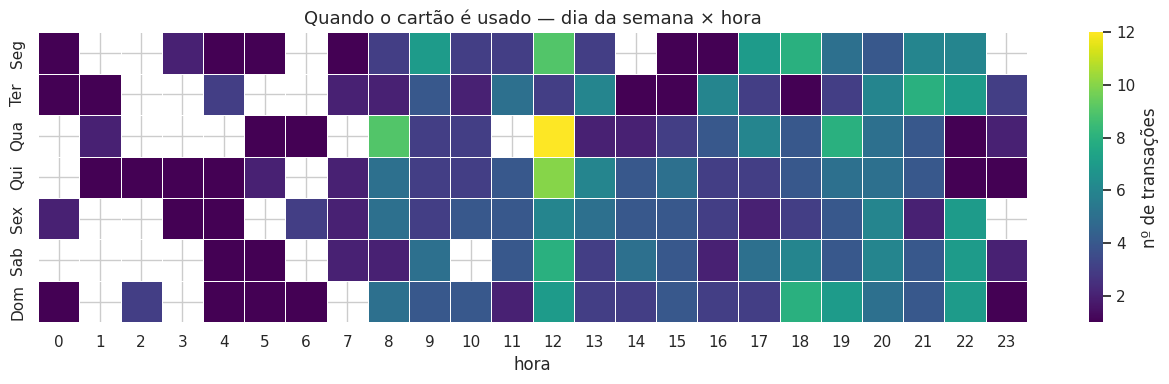

Gasto por período do dia:
periodo_do_dia
Madrugada    1,572.40
Manha       14,102.02
Tarde       30,744.80
Noite       27,647.54


In [17]:
heat = df.pivot_table(index="dia_semana_num", columns="hora",
                      values="id_transacao", aggfunc="count").rename(index=DIAS)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat, cmap="viridis", linewidths=0.4, ax=ax,
            cbar_kws={"label": "nº de transações"})
ax.set(title="Quando o cartão é usado — dia da semana × hora", xlabel="hora", ylabel="")
plt.tight_layout()
plt.show()

print("Gasto por período do dia:")
print(df.groupby("periodo_do_dia", observed=True)["valor"].sum().to_string())

### 6.5 Assinaturas recorrentes

**Pergunta 3:** quanto custam as assinaturas? Gasto "invisível" clássico: valores pequenos, mas constantes.

In [18]:
assin = df[df["is_assinatura"]]
custo_mensal_assin = assin.groupby("estabelecimento_limpo")["valor"].mean().sort_values(ascending=False)

print(f"Total no semestre: R$ {assin['valor'].sum():,.2f}")
print(f"Custo mensal fixo: R$ {custo_mensal_assin.sum():,.2f}")
print(f"Participação no gasto total: {assin['valor'].sum() / gasto_total * 100:.1f}%\n")
print("Custo mensal por serviço:")
print(custo_mensal_assin.to_string(float_format="R$ %.2f"))

Total no semestre: R$ 1,863.00
Custo mensal fixo: R$ 310.50
Participação no gasto total: 2.5%

Custo mensal por serviço:
estabelecimento_limpo
SMARTFIT                 R$ 119.90
ALURA CURSOS              R$ 75.00
NETFLIX.COM               R$ 44.90
GOOGLE *YOUTUBEPREMIUM    R$ 28.90
SPOTIFY                   R$ 21.90
AMAZON PRIME              R$ 19.90


### 6.6 Parcelamentos — compromisso futuro

**Pergunta 4:** compras parceladas comprometem faturas futuras. Medimos quanto de cada fatura já estava "contratado" por parcelas.

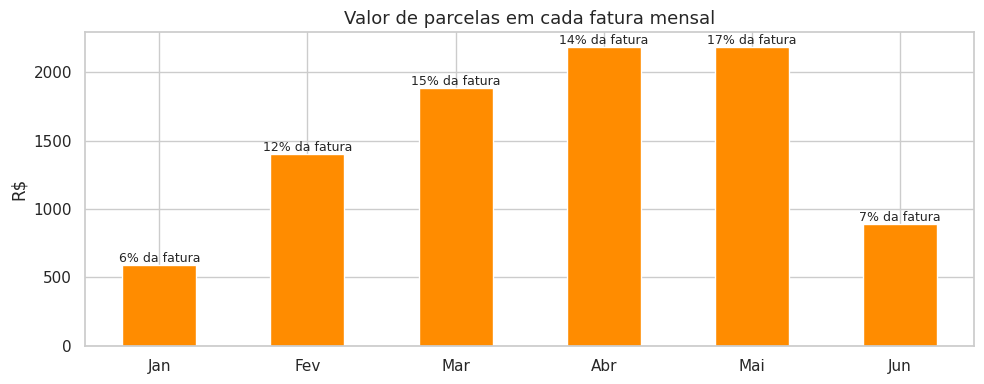

Compras parceladas na base:
                       parcelas_pagas  valor_parcela  total_parcelas
estabelecimento_limpo                                               
CASAS BAHIA                         6         189.90              10
CENTAURO                            3         299.97               3
DECOLAR.COM                         4         810.00               4
MAGAZINE LUIZA                      6         399.98               6
TOK STOK                            3         483.33               3


In [19]:
parc = df[df["tipo_pagamento"] == "credito_parcelado"]

comprometido = parc.groupby("mes")["valor"].sum().reindex(MESES.values())
pct_fatura = (comprometido / df.groupby("mes")["valor"].sum().reindex(MESES.values()) * 100)

ax = comprometido.plot(kind="bar", color="darkorange", figsize=(10, 4))
for i, (v, p) in enumerate(zip(comprometido, pct_fatura)):
    ax.text(i, v, f"{p:.0f}% da fatura", ha="center", va="bottom", fontsize=9)
ax.set(title="Valor de parcelas em cada fatura mensal", xlabel="", ylabel="R$")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Compras parceladas na base:")
print(parc.groupby("estabelecimento_limpo")
          .agg(parcelas_pagas=("valor", "count"), valor_parcela=("valor", "mean"),
               total_parcelas=("parcelas", "max"))
          .to_string(float_format="%.2f"))

### 6.7 Alimentação: fora de casa vs. supermercado

**Pergunta 5:** delivery + restaurantes vs. supermercado — clássico ponto de otimização de orçamento.

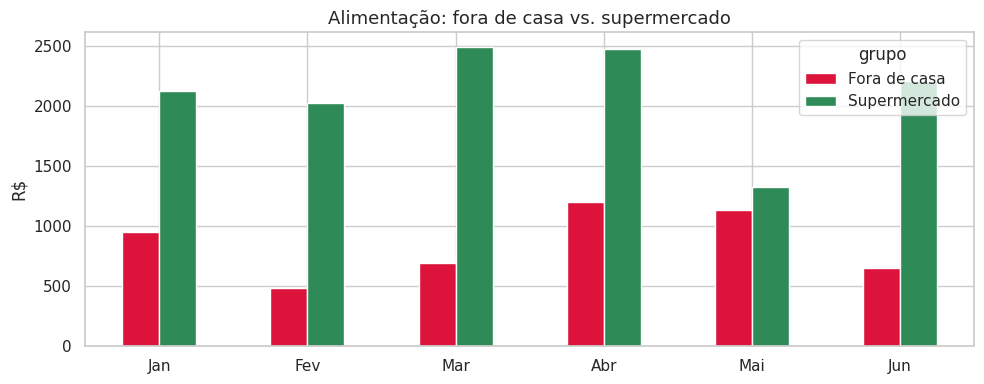

Fora de casa: R$ 5,097.67 (29% do gasto com alimentação)
Supermercado: R$ 12,641.85


In [20]:
FORA = ["Delivery", "Restaurante", "Cafeteria", "Padaria"]
CASA = ["Supermercado"]

alim = df[df["categoria"].isin(FORA + CASA)].copy()
alim["grupo"] = np.where(alim["categoria"].isin(FORA), "Fora de casa", "Supermercado")

comparativo = alim.pivot_table(index="mes_num", columns="grupo",
                               values="valor", aggfunc="sum").rename(index=MESES)
ax = comparativo.plot(kind="bar", figsize=(10, 4), color=["crimson", "seagreen"])
ax.set(title="Alimentação: fora de casa vs. supermercado", xlabel="", ylabel="R$")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

tot = alim.groupby("grupo")["valor"].sum()
print(f"Fora de casa: R$ {tot['Fora de casa']:,.2f} "
      f"({tot['Fora de casa'] / tot.sum() * 100:.0f}% do gasto com alimentação)")
print(f"Supermercado: R$ {tot['Supermercado']:,.2f}")

### 6.8 Viagem internacional e cartão adicional

**Perguntas 7 e 8:** custo da viagem a Buenos Aires (maio) e participação do cartão adicional.

In [21]:
intl = df[df["is_internacional"]]
print(f"Viagem internacional — {len(intl)} transações, total R$ {intl['valor'].sum():,.2f}")
print(intl[["data_hora", "estabelecimento_limpo", "categoria", "valor", "cidade"]]
      .to_string(index=False))
print()

por_titular = df.groupby("titular")["valor"].agg(["sum", "count"])
por_titular["% do gasto"] = por_titular["sum"] / por_titular["sum"].sum() * 100
por_titular

Viagem internacional — 5 transações, total R$ 501.60
          data_hora   estabelecimento_limpo   categoria  valor       cidade
2026-05-16 13:42:00 UBER *TRIP BUENOS AIRES  Transporte  18.50 Buenos Aires
2026-05-16 20:27:00   RESTAURANTE DON JULIO Restaurante 320.00 Buenos Aires
2026-05-18 10:28:00            CAFE TORTONI   Cafeteria  45.80 Buenos Aires
2026-05-18 17:32:00             MUSEO MALBA       Lazer  55.00 Buenos Aires
2026-05-19 16:37:00               FARMACITY    Farmacia  62.30 Buenos Aires



,sum,count,% do gasto
titular,,,
JOSUE S SILVA,"64,401.11",435,86.95
JOSUE S SILVA - ADICIONAL,"9,665.65",70,13.05


### 6.9 Outliers e distribuição de valores

Boxplot por categoria (top 8) para visualizar dispersão e compras atípicas. Outliers aqui não são erro — são compras grandes legítimas (eletrodomésticos, passagens) —, mas merecem destaque no storytelling.

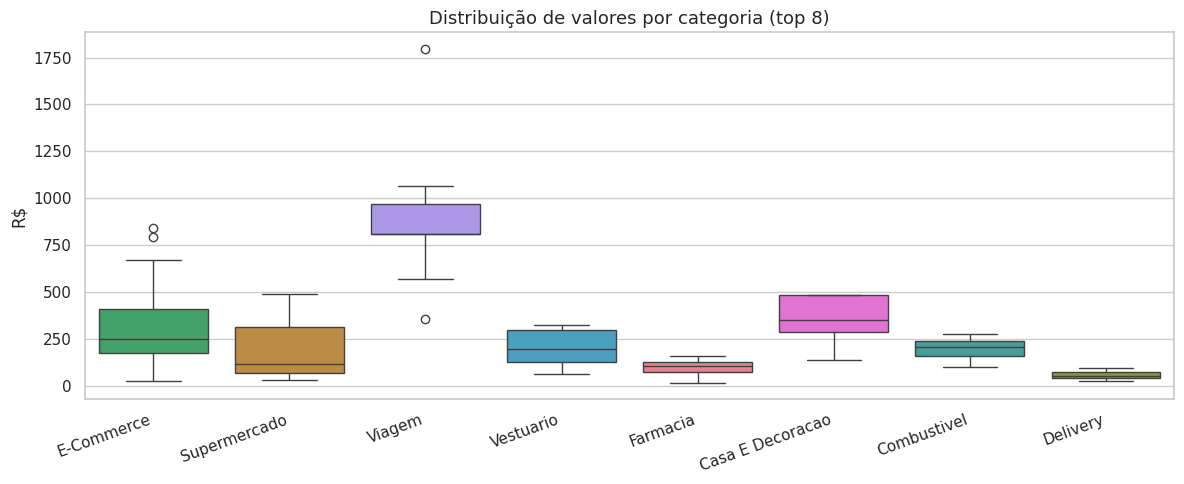

,data_hora,estabelecimento_limpo,categoria,valor
308,2026-04-24 22:17:00,DECOLAR.COM,Viagem,"1,795.42"
499,2026-06-26 08:57:48,AIRBNB * HMRSTAY,Viagem,"1,067.42"
94,2026-02-08 15:02:08,DECOLAR.COM,Viagem,"1,053.44"
245,2026-04-03 19:15:03,AIRBNB * HMRSTAY,Viagem,884.40
281,2026-04-15 17:47:09,MAGAZINE LUIZA,E-Commerce,839.13


In [22]:
top8 = por_categoria.head(8).index
dados_box = df[df["categoria"].isin(top8) & ~df["is_estorno"]]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=dados_box, x="categoria", y="valor", hue="categoria",
            order=top8, legend=False, ax=ax)
ax.set(title="Distribuição de valores por categoria (top 8)", xlabel="", ylabel="R$")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Maiores compras individuais do semestre
df.nlargest(5, "valor")[["data_hora", "estabelecimento_limpo", "categoria", "valor"]]

<a id="7"></a>
## 7. Conclusões e recomendações

**Pergunta 9:** onde cortar para economizar ~15% ao mês? A célula abaixo consolida os números e simula o corte nas frentes com maior "gordura": alimentação fora de casa, assinaturas e delivery.

In [23]:
fora_casa_mes = df[df["categoria"].isin(FORA)]["valor"].sum() / 6
assin_mes = custo_mensal_assin.sum()
media_mes = gasto_total / 6
meta = media_mes * 0.15

simulacao = pd.DataFrame({
    "Ação": [
        "Reduzir 40% do gasto fora de casa (delivery/restaurantes)",
        "Cancelar 2 streamings menos usados",
        "Substituir 1 compra parcelada futura por poupança prévia",
    ],
    "Economia mensal estimada (R$)": [
        fora_casa_mes * 0.40,
        custo_mensal_assin.iloc[-2:].sum(),
        df[df['tipo_pagamento'] == 'credito_parcelado']['valor'].sum() / 6 * 0.30,
    ],
})
simulacao.loc["TOTAL"] = ["—", simulacao["Economia mensal estimada (R$)"].sum()]

print(f"Gasto médio mensal:  R$ {media_mes:,.2f}")
print(f"Meta de economia 15%: R$ {meta:,.2f}/mês\n")
economia = simulacao.loc['TOTAL', 'Economia mensal estimada (R$)']
print(f"Economia simulada:    R$ {economia:,.2f}/mês "
      f"({economia / media_mes * 100:.1f}% do gasto médio)")
simulacao

Gasto médio mensal:  R$ 12,344.46
Meta de economia 15%: R$ 1,851.67/mês

Economia simulada:    R$ 838.10/mês (6.8% do gasto médio)


,Ação,Economia mensal estimada (R$)
0,Reduzir 40% do gasto fora de casa (delivery/re...,339.84
1,Cancelar 2 streamings menos usados,41.80
2,Substituir 1 compra parcelada futura por poupa...,456.46
TOTAL,—,838.10


In [24]:
# Resumo executivo gerado dinamicamente a partir dos dados
print("=" * 70)
print("RESUMO EXECUTIVO")
print("=" * 70)
top_cat = por_categoria.index[0]
print(f"""
1. Gasto líquido de R$ {gasto_total:,.2f} no semestre (média de
   R$ {media_mes:,.2f}/mês), com variação de {var_pct:+.1f}% entre jan e jun.

2. '{top_cat}' é a categoria de maior peso
   ({por_categoria.iloc[0]['% do total']:.1f}% do total). Alimentação fora de casa
   consome R$ {fora_casa_mes:,.2f}/mês — principal alvo de economia.

3. Assinaturas somam R$ {assin_mes:,.2f}/mês fixos
   ({assin['valor'].sum() / gasto_total * 100:.1f}% do semestre) — revisar itens pouco usados.

4. Parcelamentos comprometem parte relevante das faturas futuras;
   planejar compras grandes evita efeito bola de neve.

5. O plano simulado atinge economia de R$ {economia:,.2f}/mês
   ({economia / media_mes * 100:.0f}% do gasto médio), cumprindo a meta de 15%.
""")

RESUMO EXECUTIVO

1. Gasto líquido de R$ 74,066.76 no semestre (média de
   R$ 12,344.46/mês), com variação de +31.8% entre jan e jun.

2. 'E-Commerce' é a categoria de maior peso
   (30.4% do total). Alimentação fora de casa
   consome R$ 849.61/mês — principal alvo de economia.

3. Assinaturas somam R$ 310.50/mês fixos
   (2.5% do semestre) — revisar itens pouco usados.

4. Parcelamentos comprometem parte relevante das faturas futuras;
   planejar compras grandes evita efeito bola de neve.

5. O plano simulado atinge economia de R$ 838.10/mês
   (7% do gasto médio), cumprindo a meta de 15%.



<a id="8"></a>
## 8. Rastreabilidade — números do dashboard

O projeto inclui um dashboard interativo (`dashboard.html`). **Todos os números exibidos nele são calculados nesta seção**, garantindo auditabilidade: se um valor aparece no dashboard, a conta que o gerou está aqui.

### 8.1 KPIs do topo (página Visão Executiva)

In [25]:
# KPI 1 — Gasto do último mês e variação vs. média do semestre
gasto_jun = df[df["mes_num"] == 6]["valor"].sum()
delta_jun = (gasto_jun / media_mes - 1) * 100

# KPI 2 — Parcelas: média mensal comprometida no semestre
parc_mes_medio = df[df["tipo_pagamento"] == "credito_parcelado"]["valor"].sum() / 6
pct_comprometido = parc_mes_medio / media_mes * 100

# KPI 3 — Assinaturas: custo mensal fixo e anualizado
assin_ano = assin_mes * 12

# KPI 4 — Tickets (sem estornos)
compras = df[~df["is_estorno"]]

pd.DataFrame({
    "KPI": ["Gasto de junho", "Delta vs média semestre", "Parcelas (média/mês)",
            "% fatura comprometida", "Assinaturas/mês", "Assinaturas/ano",
            "Ticket médio", "Ticket mediana", "Ticket p95", "Nº de compras"],
    "Valor": [f"R$ {gasto_jun:,.2f}", f"{delta_jun:+.1f}%", f"R$ {parc_mes_medio:,.2f}",
              f"{pct_comprometido:.1f}%", f"R$ {assin_mes:,.2f}", f"R$ {assin_ano:,.2f}",
              f"R$ {compras['valor'].mean():,.2f}", f"R$ {compras['valor'].median():,.2f}",
              f"R$ {compras['valor'].quantile(0.95):,.2f}", f"{len(compras)}"],
})

,KPI,Valor
0,Gasto de junho,"R$ 12,034.64"
1,Delta vs média semestre,-2.5%
2,Parcelas (média/mês),"R$ 1,521.53"
3,% fatura comprometida,12.3%
4,Assinaturas/mês,R$ 310.50
5,Assinaturas/ano,"R$ 3,726.00"
6,Ticket médio,R$ 149.54
7,Ticket mediana,R$ 76.09
8,Ticket p95,R$ 483.33
9,Nº de compras,502


### 8.2 Gasto mensal e participação por categoria

In [26]:
tab_mensal = df.groupby(["mes_num", "mes"])["valor"].sum().reset_index()
tab_mensal["% vs média"] = (tab_mensal["valor"] / media_mes - 1) * 100
print(tab_mensal.to_string(index=False))
print(f"\nTotal semestre: R$ {gasto_total:,.2f} | Média: R$ {media_mes:,.2f} "
      f"| CV: {tab_mensal['valor'].std() / tab_mensal['valor'].mean() * 100:.1f}%")

 mes_num mes     valor  % vs média
       1 Jan  9,133.52      -26.01
       2 Fev 11,356.27       -8.01
       3 Mar 12,812.59        3.79
       4 Abr 16,070.35       30.18
       5 Mai 12,659.39        2.55
       6 Jun 12,034.64       -2.51

Total semestre: R$ 74,066.76 | Média: R$ 12,344.46 | CV: 18.3%


In [27]:
tab_cat = por_categoria[["total", "% do total"]].copy()
tab_cat["% acumulado"] = tab_cat["% do total"].cumsum()
tab_cat.head(12)

,total,% do total,% acumulado
categoria,,,
E-Commerce,"22,535.53",30.43,30.43
Supermercado,"12,641.85",17.07,47.49
Viagem,"9,772.55",13.19,60.69
Vestuario,"5,273.89",7.12,67.81
Farmacia,"3,694.25",4.99,72.80
Casa E Decoracao,"3,075.77",4.15,76.95
Combustivel,"2,762.25",3.73,80.68
Delivery,"2,418.86",3.27,83.94
Transporte,"2,177.80",2.94,86.88


### 8.3 Pareto de estabelecimentos (concentração do gasto)

In [28]:
pareto = (df.groupby("estabelecimento_limpo")["valor"]
            .agg(total="sum", transacoes="count")
            .sort_values("total", ascending=False))
pareto["% acumulado"] = pareto["total"].cumsum() / df["valor"].sum() * 100
print(pareto.head(10).to_string(float_format="%.2f"))
print(f"\nTop 10 concentram {pareto['% acumulado'].iloc[9]:.1f}% do gasto total.")

                             total  transacoes  % acumulado
estabelecimento_limpo                                      
MAGAZINE LUIZA             9231.05          18        12.46
AMAZON BR                  7486.10          22        22.57
DECOLAR.COM                6446.31           7        31.27
CARREFOUR HIPER            5702.06          19        38.97
SUPERMERCADO PAO DE ACUCAR 4724.59          19        45.35
MERCADOLIVRE*MERCADOPAGO   4017.53          17        50.78
TOK STOK                   3075.77           9        54.93
POSTO SHELL                2762.25          14        58.66
RENNER                     2675.68          13        62.27
IFOOD *RESTAURANTE         1956.85          32        64.91

Top 10 concentram 64.9% do gasto total.


### 8.4 Hábitos e alertas (números das páginas Comportamento e Alertas)

In [29]:
fds = df[df["dia_semana_num"] >= 5]["valor"].sum()
noite = df[df["hora"] >= 18]["valor"].sum()
pico = df.groupby("hora")["valor"].count().idxmax()
delivery = df[df["categoria"] == "Delivery"]
grandes = df[df["valor"] > 500]
adicional = df[df["titular"].str.contains("ADICIONAL")]["valor"].sum()
abril = df[df["mes_num"] == 4]["valor"].sum()

print(f"Fim de semana:        {fds / gasto_total * 100:.1f}% do gasto (R$ {fds:,.2f})")
print(f"Após 18h:             {noite / gasto_total * 100:.1f}% (R$ {noite:,.2f})")
print(f"Hora de pico (nº tx): {pico}h")
print(f"Delivery:             {len(delivery)} pedidos = {len(delivery) / 26:.1f}/semana | R$ {delivery['valor'].sum():,.2f}")
print(f"Compras > R$ 500:     {len(grandes)} tx = {grandes['valor'].sum() / gasto_total * 100:.1f}% do gasto")
print(f"Cartão adicional:     {adicional / gasto_total * 100:.1f}% (R$ {adicional:,.2f})")
print(f"Alerta abril:         {(abril / media_mes - 1) * 100:+.1f}% vs média do semestre")

Fim de semana:        29.9% do gasto (R$ 22,181.60)
Após 18h:             37.3% (R$ 27,647.54)
Hora de pico (nº tx): 12h
Delivery:             44 pedidos = 1.7/semana | R$ 2,418.86
Compras > R$ 500:     21 tx = 22.4% do gasto
Cartão adicional:     13.0% (R$ 9,665.65)
Alerta abril:         +30.2% vs média do semestre


### 8.5 Projeção de parcelas futuras (página Planejamento)

Para cada compra parcelada, comparamos o total de parcelas contratadas com as já pagas até junho; o saldo é projetado nos meses seguintes.

In [30]:
parc = df[df["tipo_pagamento"] == "credito_parcelado"]
status = (parc.groupby("estabelecimento_limpo")
              .agg(valor_parcela=("valor", "mean"),
                   pagas=("num_parcela", "max"),
                   contratadas=("parcelas", "max"),
                   ultima=("data_hora", "max")))
status["restantes"] = status["contratadas"] - status["pagas"]
print(status.to_string(float_format="%.2f"))

# Projeção mês a mês (jul-dez/2026)
proj = {}
for _, r in status.iterrows():
    for k in range(1, int(r["restantes"]) + 1):
        m = int(r["ultima"].month) + k
        if m <= 12:
            proj[m] = proj.get(m, 0) + r["valor_parcela"]
MESES_2 = {7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"}
print("\nComprometido nas próximas faturas:")
for m in sorted(proj):
    print(f"  {MESES_2[m]}/2026: R$ {proj[m]:,.2f}")
print(f"Total ainda a pagar: R$ {sum(proj.values()):,.2f}")

                       valor_parcela  pagas  contratadas              ultima  restantes
estabelecimento_limpo                                                                  
CASAS BAHIA                   189.90      6           10 2026-06-21 12:28:00          4
CENTAURO                      299.97      3            3 2026-06-11 19:19:00          0
DECOLAR.COM                   810.00      4            4 2026-05-04 18:12:00          0
MAGAZINE LUIZA                399.98      6            6 2026-06-13 14:24:00          0
TOK STOK                      483.33      3            3 2026-05-07 21:50:00          0

Comprometido nas próximas faturas:
  Jul/2026: R$ 189.90
  Ago/2026: R$ 189.90
  Set/2026: R$ 189.90
  Out/2026: R$ 189.90
Total ainda a pagar: R$ 759.60


### 8.6 Parâmetros do simulador de economia

O simulador do dashboard usa como base os gastos médios mensais por grupo, calculados abaixo. A economia exibida é `gasto_mensal_do_grupo x % de redução escolhido no slider`.

In [31]:
base_simulador = {
    "Alimentação fora (Delivery/Restaurante/Cafeteria/Padaria)": df[df["categoria"].isin(FORA)]["valor"].sum() / 6,
    "E-commerce": df[df["categoria"] == "E-Commerce"]["valor"].sum() / 6,
    "Vestuário": df[df["categoria"] == "Vestuario"]["valor"].sum() / 6,
    "Assinaturas (cancelamento por serviço)": assin_mes,
}
for k, v in base_simulador.items():
    print(f"  {k}: R$ {v:,.2f}/mês")
print(f"\nMeta de economia (15% da média mensal): R$ {media_mes * 0.15:,.2f}")

  Alimentação fora (Delivery/Restaurante/Cafeteria/Padaria): R$ 849.61/mês
  E-commerce: R$ 3,755.92/mês
  Vestuário: R$ 878.98/mês
  Assinaturas (cancelamento por serviço): R$ 310.50/mês

Meta de economia (15% da média mensal): R$ 1,851.67


### 8.7 Exportação dos dados limpos

Exportamos a base tratada em dois formatos: CSV (consumo geral) e JSON compacto (embutido no `dashboard.html` — o dashboard filtra e agrega estas transações em tempo real no navegador).

In [32]:
import json

df_export = df[["id_transacao", "data_hora", "estabelecimento_limpo", "categoria",
                "valor", "cidade", "pais", "tipo_pagamento", "parcelas",
                "num_parcela", "titular", "is_assinatura", "is_estorno"]].copy()
df_export.to_csv("extrato_cartao_2026_limpo.csv", index=False)

registros = [[r.id_transacao, r.data_hora.strftime("%Y-%m-%dT%H:%M"),
              r.estabelecimento_limpo, r.categoria, round(r.valor, 2), r.cidade,
              r.pais, r.tipo_pagamento, int(r.parcelas),
              int(r.num_parcela) if pd.notna(r.num_parcela) else None,
              "ADICIONAL" if "ADICIONAL" in r.titular else "TITULAR",
              bool(r.is_assinatura)]
             for r in df_export.itertuples()]
with open("dados_dashboard.json", "w", encoding="utf-8") as f:
    json.dump(registros, f, ensure_ascii=False, separators=(",", ":"))
print(f"Exportados: extrato_cartao_2026_limpo.csv e dados_dashboard.json ({len(registros)} transações)")

Exportados: extrato_cartao_2026_limpo.csv e dados_dashboard.json (505 transações)


---

### Limitações e próximos passos

- **Base sintética**: gerada por script para fins de portfólio; o pipeline, porém, é o mesmo aplicável a um extrato real.
- **Próximos passos**: dashboard interativo (Streamlit/Power BI), categorização automática de estabelecimentos com regras/ML, e detecção de anomalias para alertas de fraude.

*Ferramentas: Python, pandas, numpy, matplotlib, seaborn.*